**Libraries Import**

In [ ]:
# Python code to read image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:
# prompt: import image from google drive

from google.colab import drive
drive.mount('/content/drive')

import cv2
import os

# Construct the image path
image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'lane_line_1.jpg')
# Check if the file exists
if os.path.exists(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Check if the image was loaded successfully
    if img is not None:
        print("Image loaded successfully!")
        print(img.shape)
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")


Mounted at /content/drive
Image loaded successfully!
(499, 700, 3)


**Gaussian blur**

Gaussian blur smooths an image by averaging the pixel values in a neighborhood, weighted by a Gaussian function. 1  Pixels closer to the center of the neighborhood have a higher weight, resulting in a softer, more natural blur compared to a simple average. 2  It reduces noise and fine details.

Image loaded successfully!
(499, 700, 3)


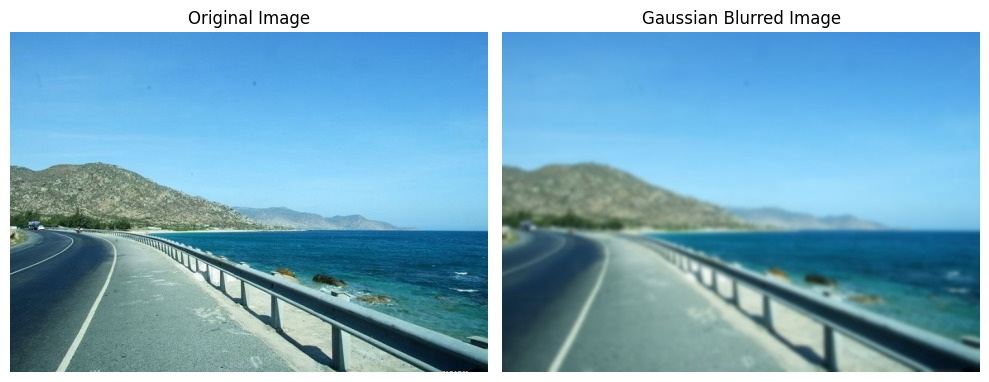

In [ ]:
image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'lane_line_1.jpg')
# Check if the file exists
if os.path.exists(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Check if the image was loaded successfully
    if img is not None:
        print("Image loaded successfully!")
        print(img.shape)
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")

blurred_image_g = cv2.GaussianBlur(img, (15, 15), 0)


import matplotlib.pyplot as plt

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(blurred_image_g, cv2.COLOR_BGR2RGB))
axes[1].set_title('Gaussian Blurred Image')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Median Blur**

Median blur replaces each pixel's value with the median value of its neighboring pixels within a kernel. 1  This is particularly effective at removing "salt and pepper" noise (random black and white pixels) while preserving edges better than a simple averaging blur because the median value is always an existing pixel value and is less affected by extreme outliers.

Image loaded successfully!
(499, 700, 3)


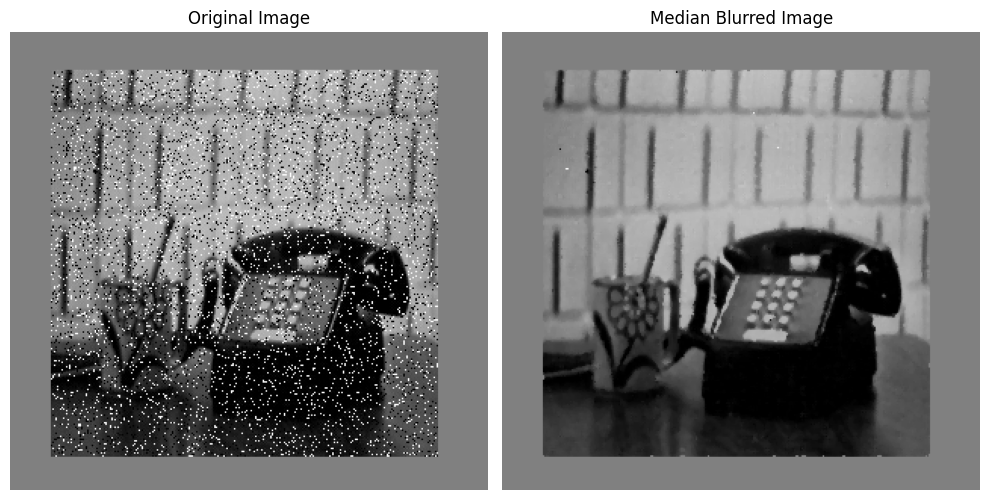

In [ ]:
image_path_noise = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'noise.png')
# Check if the file exists
if os.path.exists(image_path):
    noise = cv2.imread(image_path_noise, cv2.IMREAD_COLOR)

    # Check if the image was loaded successfully
    if img is not None:
        print("Image loaded successfully!")
        print(img.shape)
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")

blurred_image_m = cv2.medianBlur(noise, 3)


import matplotlib.pyplot as plt

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(noise, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(blurred_image_m, cv2.COLOR_BGR2RGB))
axes[1].set_title('Median Blurred Image')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Average blur**

Average blur, also known as mean blur or box blur, smooths an image by replacing each pixel's value with the average intensity value of its surrounding neighbors within a defined kernel or window. All pixels within the kernel contribute equally to the average. This results in a blurring effect that reduces sharp edges and noise. Larger kernel sizes produce a more significant blur

Image loaded successfully!
(499, 700, 3)


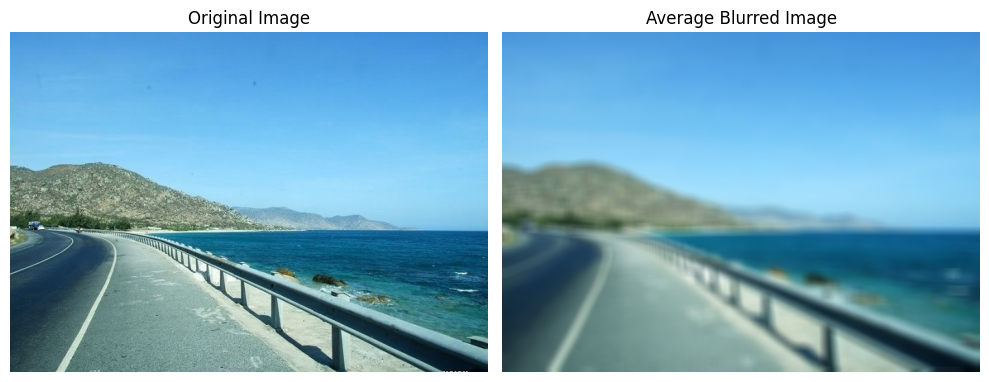

In [ ]:
image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'lane_line_1.jpg')
# Check if the file exists
if os.path.exists(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # Check if the image was loaded successfully
    if img is not None:
        print("Image loaded successfully!")
        print(img.shape)
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")

blurred_image_a = cv2.blur(img, (15, 15))

import matplotlib.pyplot as plt

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(blurred_image_a, cv2.COLOR_BGR2RGB))
axes[1].set_title('Average Blurred Image')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Segmentation**

✈ Image segmentation in OpenCV is the process of dividing an image into multiple regions or segments, often based on pixel characteristics like color or intensity. The goal is to simplify the image for analysis or to isolate objects of interest.

OpenCV offers various techniques for image segmentation, including:

* Thresholding: Separating pixels into different regions based on their intensity
values. Simple but effective for images with distinct foreground and background.
*  Color-based Segmentation: Grouping pixels with similar colors together. Useful when objects have unique color profiles.
*  Edge Detection: Identifying boundaries between regions based on sharp changes in pixel intensity. Can be a precursor to region-based segmentation.
*  Region Growing: Starting with seed pixels and iteratively adding neighboring pixels that meet certain criteria (e.g., similar color or intensity).
*  Watershed Algorithm: Treating the image as a topographic map, flooding it from multiple source points, and creating boundaries where the "water" meets. *  Effective for separating touching objects.
*  Clustering (e.g., K-Means): Grouping pixels into clusters based on feature similarity (like color and texture).
*  Graph-based Segmentation: Representing the image as a graph and finding cuts that separate regions based on pixel similarities.
*  Interactive Segmentation (e.g., GrabCut): Allowing users to define foreground and background regions to refine the segmentation.
*  Deep Learning-based Segmentation (Semantic and Instance Segmentation): Using neural networks to classify each pixel into a specific category (semantic) or to identify and segment individual object instances (instance).
The choice of method depends on the specific characteristics of the image and the desired outcome of the segmentation.

1.   Import libraries
2.   Read image




In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/drive')

import os

# Construct the image path
image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'lane_line_2.jpg')
# Check if the file exists
if os.path.exists(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    original_image = image.copy()

    # Check if the image was loaded successfully
    if image is not None:
        print("Image loaded successfully!")
        print(image.shape)
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image loaded successfully!
(432, 768, 3)


**Grayscale the image**



> Syntax: cv2.cvtColor(src, code[, dst[, dstCn]])

> return: Image in gray scale

> Parameters:src: It is the image whose color space is to be changed. code: It is the color space conversion code. dst: It is the output image of the same size and depth as src image. It is an optional parameter. dstCn: It is the number of channels in the destination image. If the parameter is 0 then the number of the channels is derived automatically from src and code. It is an optional parameter.  Return Value: It returns an image.



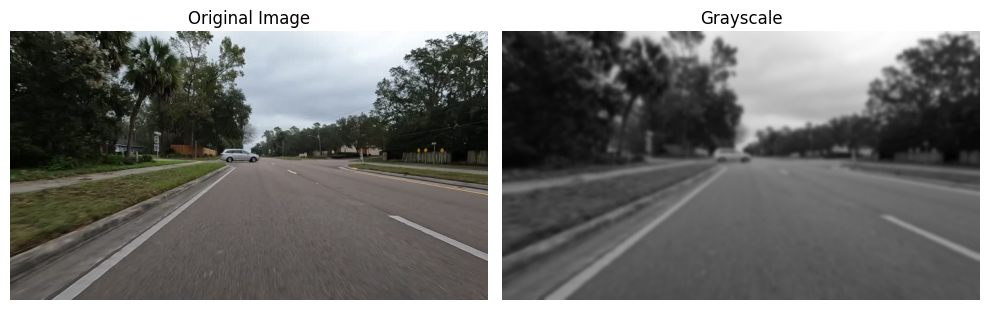

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (15, 15), 0)

import matplotlib.pyplot as plt

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
axes[1].set_title('Grayscale')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Thresholding Image**

Convert the image into binary image

---
```
cv2.threshold(source, thresholdValue, maxVal, thresholdingTechnique)
```


> Parameters:
-  source: Input Image array (must be in Grayscale).
-  thresholdValue: Value of Threshold below and above which pixel values will change accordingly.
-  maxVal: Maximum value that can be assigned to a pixel.
-  thresholdingTechnique: The type of thresholding to be applied.

*Thresholding Technique*

-  cv.THRESH_BINARY
-  cv.THRESH_BINARY_INV
-  cv.THRESH_TRUNC
-  cv.THRESH_TOZERO
-  cv.THRESH_TOZERO_INV

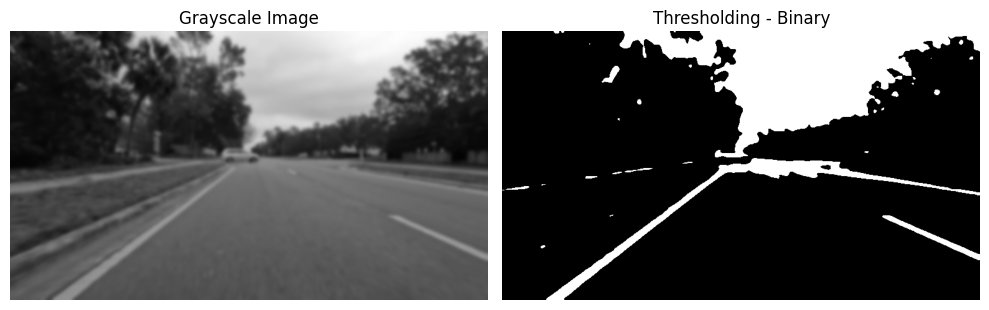

In [ ]:
ret, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Grayscale Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(thresh, cv2.COLOR_BGR2RGB))
axes[1].set_title('Thresholding - Binary')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Find and Draw Contours**

```
cv.findContours(image, mode, method[, contours[, hierarchy[, offset]]])
```
-	 Return: contours, hierarchy

```
cv.drawContours(image, contours, contourIdx, color[, thickness[, lineType[, hierarchy[, maxLevel[, offset]]]]])
```
-  Return: image


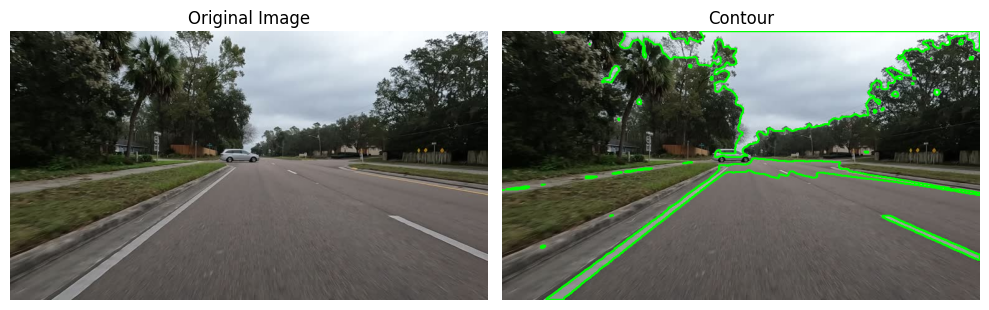

In [ ]:
# Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Draw contours
cv2.drawContours(image, contours, -1, (0, 255, 0), 2)

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Contour')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Analyze contours**

**Segmented Image**

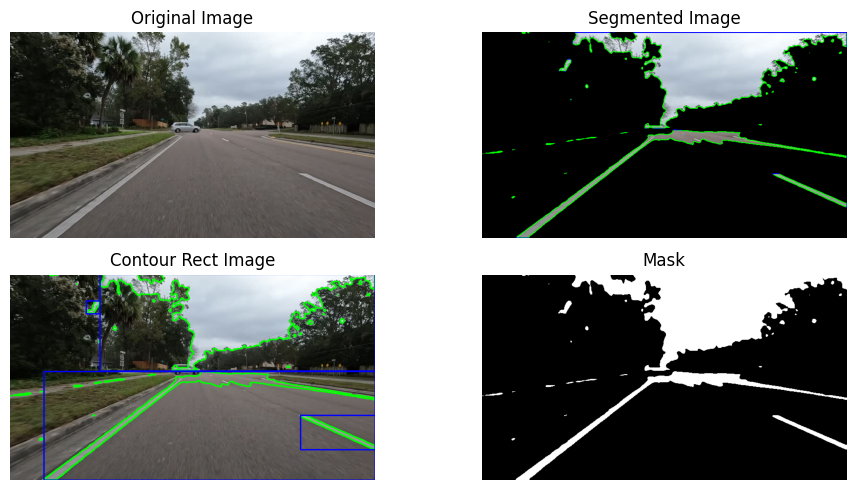

In [ ]:
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 100: # Filter by area
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Create a mask
mask = np.zeros_like(gray)
cv2.drawContours(mask, contours, -1, 255, cv2.FILLED)
# Apply the mask
segmented_image = cv2.bitwise_and(image, image, mask=mask)

# Create a figure and axes
fig, axes = plt.subplots(2, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0][0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0][0].set_title('Original Image')
axes[0][0].axis('off')  # Hide axes

# Display the second image
axes[0][1].imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))
axes[0][1].set_title('Segmented Image')
axes[0][1].axis('off')

# Display the second image
axes[1][0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1][0].set_title('Contour Rect Image')
axes[1][0].axis('off')

# Display the second image
axes[1][1].imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))
axes[1][1].set_title('Mask')
axes[1][1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Feature Detection**

----
In this section, we will try detecting some traffic sign
-  Using color
-  Using shape

**Using shape**

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/drive')

import os

# Construct the image path
image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'no-turn-right-1.jpg')

# try this to see the differences
#image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'no-turn-right.jpg')

# Check if the file exists
if os.path.exists(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    original_image = image.copy()

    # Check if the image was loaded successfully
    if image is not None:
        print("Image loaded successfully!")
        print(image.shape)
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image loaded successfully!
(510, 510, 3)


**Define Is Circular Function**

```
Check if a contour is a circle or not
```





In [ ]:
def is_circular(contour, tolerance=0.2):
    """
    Checks if a contour is approximately a circle.

    Args:
        contour: A contour point array (e.g., from cv2.findContours).
        tolerance: A small float to account for imperfections.

    Returns:
        True if the contour is approximately a circle, False otherwise.
    """
    # Calculate the area and perimeter of the contour
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    # If the perimeter is zero, it's not a valid shape
    if perimeter == 0:
        return False

    # Calculate the circularity using the formula: 4 * pi * area / (perimeter * perimeter)
    circularity = 4 * np.pi * area / (perimeter * perimeter)
    print(area, perimeter, circularity)

    # A perfect circle has a circularity of 1. Check if it's within the tolerance.
    return 1 - tolerance <= circularity <= 1 + tolerance

**Proccess the image**

Blur the image

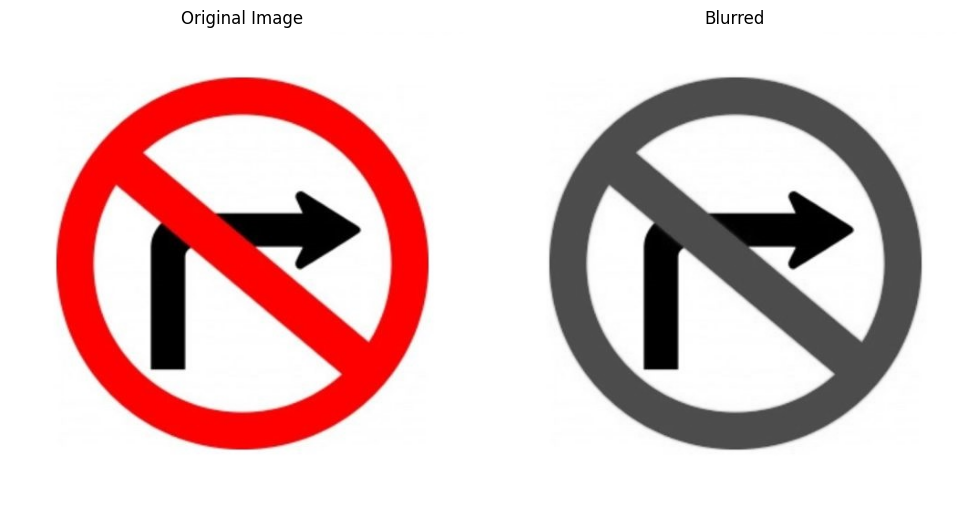

In [ ]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
# blurred = cv2.GaussianBlur(gray, (1, 1), 0)
blurred = gray

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axes[1].set_title('Blurred')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

Perform Edge Detection using Canny

```
cv2.Canny(image, T_lower, T_upper, aperture_size, L2Gradient)
```
> Return Value: Returns an image with detected edges where edges are marked in white (255) and non-edges in black (0).

Where:

-  Image: Input image to which Canny filter will be applied.
-  T_lower: Lower threshold value in Hysteresis Thresholding.
-  T_upper: Upper threshold value in Hysteresis Thresholding.
-  aperture_size: Aperture size of Sobel filter.
-  L2Gradient: Boolean parameter used for more precision in calculating Edge Gradient.

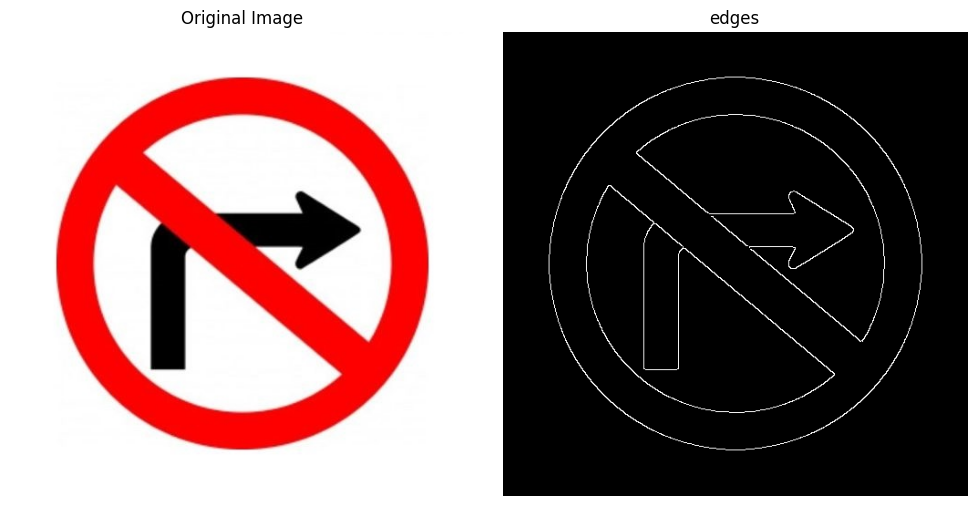

In [ ]:
edges = cv2.Canny(blurred, 10, 150)

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
axes[1].set_title('edges')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

Loop contours and apply is circular function

131017.0 1354.8224968910217 0.8969592559491045


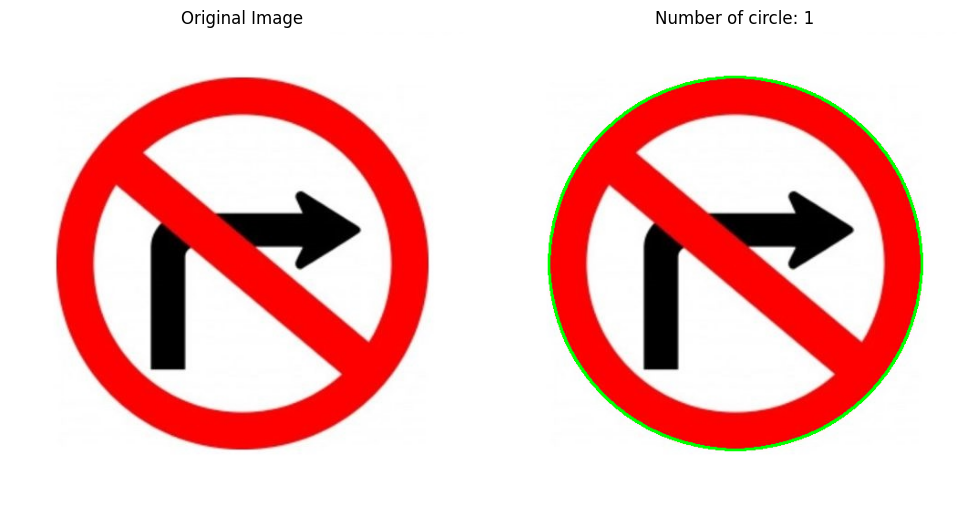

In [ ]:
# Find contours
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Iterate through the contours and check for squares
cicular_contours = []
for contour in contours:
    if is_circular(contour):
        cicular_contours.append(contour)

# Draw the detected squares on the original image
cv2.drawContours(image, cicular_contours, -1, (0, 255, 0), 2)

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Number of circle: ' + str(len(cicular_contours)))
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Object Detection**

Face detection

In [ ]:
!pip install opencv_python
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/drive')

import os

# Construct the image path
image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'face-haar.webp')

# try this to see the differences
#image_path = os.path.join('/content/drive/MyDrive/Colab Notebooks/images', 'no-turn-right.jpg')

# Check if the file exists
if os.path.exists(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    original_image = image.copy()

    # Check if the image was loaded successfully
    if image is not None:
        print("Image loaded successfully!")
        print(image.shape)
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print(f"Error: Image file not found at {image_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image loaded successfully!
(417, 346, 3)


You can use this image from internet

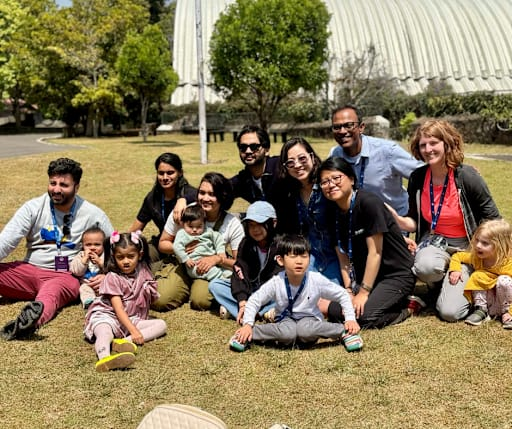

In [ ]:
# prompt: read image from this link https://resources.finalsite.net/images/f_auto,q_auto,t_image_size_2/v1742889113/kisin/ux1jt6nxcj0msleczhq3/2005.png

import numpy as np
import requests
from PIL import Image
from io import BytesIO

url = "https://resources.finalsite.net/images/f_auto,q_auto,t_image_size_2/v1742889113/kisin/ux1jt6nxcj0msleczhq3/2005.png"
response = requests.get(url)
img_pil = Image.open(BytesIO(response.content))
image = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR) # Convert from PIL to OpenCV format
original_image = image.copy()

# Display the image using cv2_imshow
cv2_imshow(image)

**Proccessing**

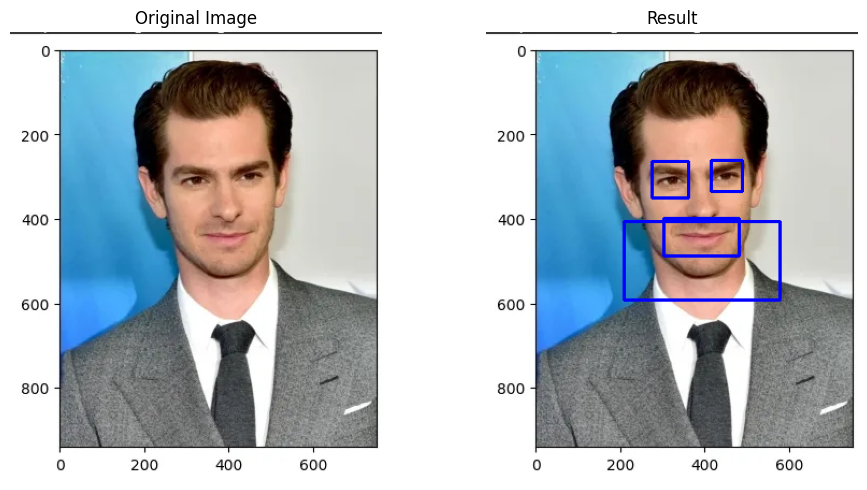

In [ ]:
import matplotlib.pyplot as plt

# Load the pre-trained Haar Cascade for face detection

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')
# face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface_extended.xml')

# Check if the cascade classifier is loaded correctly
if face_cascade.empty():
    raise IOError('Unable to load the face cascade classifier XML file.')

# Read the image
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces
# faces = face_cascade.detectMultiScale(
#     gray,
#     scaleFactor=1.1,  # Smaller steps, more thorough
#     minNeighbors=10,   # A good balance for quality vs. missed detections
#     minSize=(10, 10), # Adjust based on the smallest face you expect
#     # maxSize=(200, 200) # Optional: Set a max size if very large faces are false positives
#     flags=cv2.CASCADE_SCALE_IMAGE # Generally recommended for better results
# )

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,         # How much the image size is reduced at each image scale.
                             # Smaller values (e.g., 1.05) increase accuracy by checking more scales
                             # but slow down detection. Larger values (e.g., 1.2) are faster
                             # but might miss smaller faces.
    minNeighbors=10,         # How many neighbors each candidate rectangle should have to retain it.
                             # Higher values (e.g., 8-15) result in fewer false positives but
                             # might miss some true positives. Lower values (e.g., 3-5)
                             # detect more faces but also more false positives.
    minSize=(5, 5),        # Minimum possible object size. Objects smaller than this are ignored.
                             # This should be tuned to the smallest face size you expect in the image.
                             # Start with (30, 30) and adjust as needed.
    maxSize=(300, 300),      # Maximum possible object size. Objects larger than this are ignored.
                             # Useful for ignoring very large objects that might be false positives,
                             # or if you know faces won't exceed a certain size.
    flags=cv2.CASCADE_SCALE_IMAGE # Mode of operation. This flag is generally recommended
                                 # for better results and tells the function to scale the image
                                 # rather than the detector.
)

# Draw rectangles around the faces
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the second image
axes[1].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Result')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
# prompt: example of python opencv Erosion for google colab show it on matplotlib with image from internet

import matplotlib.pyplot as plt
import numpy as np
# Example of Erosion

# Load an image from the internet
url = "https://i.imgur.com/BfR6xJz.png" # Example of a simple binary image
response = requests.get(url)
img_pil = Image.open(BytesIO(response.content)).convert('L') # Convert to grayscale
image = cv2.cvtColor(np.array(img_pil), cv2.COLOR_GRAY2BGR) # Convert grayscale to BGR for matplotlib display

# Create a kernel for erosion
kernel = np.ones((5,5),np.uint8)

# Apply erosion
eroded_image = cv2.erode(image, kernel, iterations = 1)

# Create a figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the original image
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
axes[0].set_title('Original Image')
axes[0].axis('off')  # Hide axes

# Display the eroded image
axes[1].imshow(cv2.cvtColor(eroded_image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Eroded Image')
axes[1].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x79d78c2b3420>